# 01. Разведочный анализ данных (EDA)

**Датасет:** Telco Customer Churn (IBM, открытый).
**Цель:** понять структуру данных, баланс классов, пропуски, распределения признаков перед построением моделей.

Целевая переменная — `Churn` (Yes/No → 1/0): ушёл ли клиент в течение последнего месяца.

In [1]:
import sys
from pathlib import Path

# чтобы импортировать из src/
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load import load_raw, load_clean

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

# сюда сохраняем рисунки для отчёта
FIG_DIR = PROJECT_ROOT / 'artifacts' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка сырых данных

In [2]:
raw = load_raw(PROJECT_ROOT / 'data' / 'raw' / 'telco_churn.csv')
print('Размер:', raw.shape)
raw.head()

Размер: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Наблюдение:** колонка `TotalCharges` распознаётся как `object` — внутри есть пробелы для клиентов с `tenure=0`. Это нужно обработать (см. `src/data/load.py::clean`).

In [4]:
# проверка проблемных значений TotalCharges
mask = pd.to_numeric(raw['TotalCharges'], errors='coerce').isna()
print('Строк с некорректным TotalCharges:', mask.sum())
raw.loc[mask, ['tenure', 'TotalCharges', 'MonthlyCharges']].head()

Строк с некорректным TotalCharges: 11


,tenure,TotalCharges,MonthlyCharges
488,0,,52.55
753,0,,20.25
936,0,,80.85
1082,0,,25.75
1340,0,,56.05


## 2. Очистка

In [5]:
df = load_clean(PROJECT_ROOT / 'data' / 'raw' / 'telco_churn.csv')
print('После очистки:', df.shape)
print('Пропуски:', df.isna().sum().sum())
df.dtypes

После очистки: (7043, 20)
Пропуски: 0


gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

## 3. Баланс классов

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


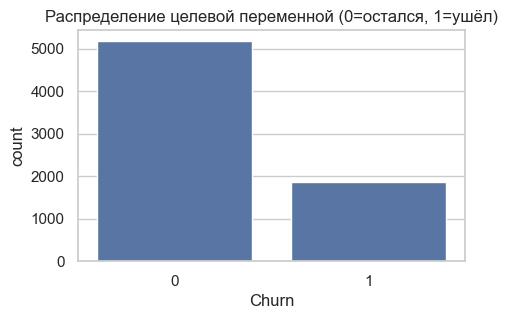

In [6]:
vc = df['Churn'].value_counts(normalize=True)
print(vc)
fig, ax = plt.subplots(figsize=(5, 3))
sns.countplot(x='Churn', data=df, ax=ax)
ax.set_title('Распределение целевой переменной (0=остался, 1=ушёл)')
fig.savefig(FIG_DIR / 'fig_target_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

**Наблюдение:** классы несбалансированы — отток ~26.5%. Поэтому метрика accuracy будет вводить в заблуждение; будем смотреть на ROC-AUC, F1, precision/recall. В моделях используем `class_weight='balanced'`.

## 4. Распределения числовых признаков

In [7]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


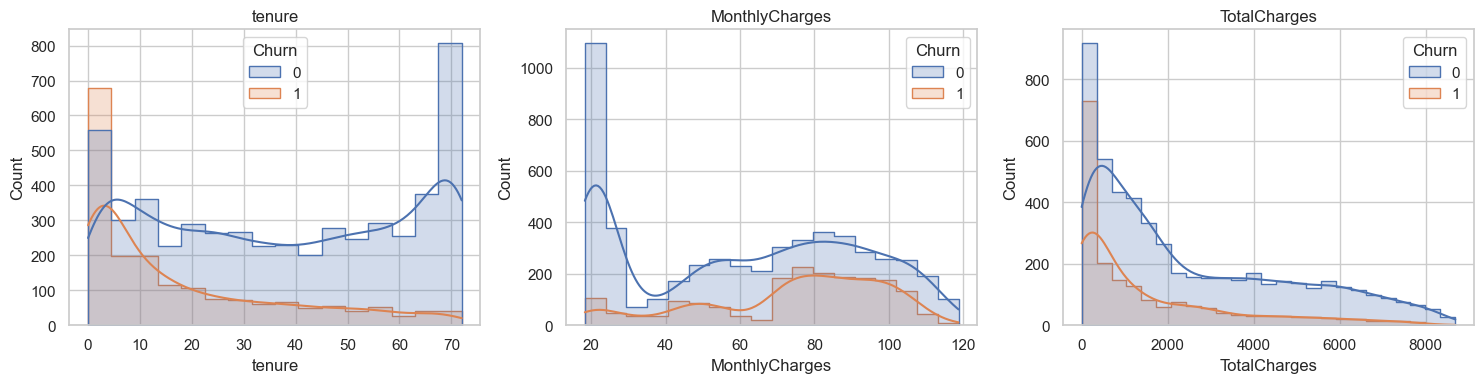

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax, element='step')
    ax.set_title(col)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_numeric_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

**Наблюдения:**
- `tenure`: ушедшие клиенты в основном новички (короткий tenure) — сильный сигнал для модели.
- `MonthlyCharges`: у ушедших сдвиг в сторону более высоких платежей.
- `TotalCharges` коррелирует с tenure (что логично).

## 5. Категориальные признаки vs Churn

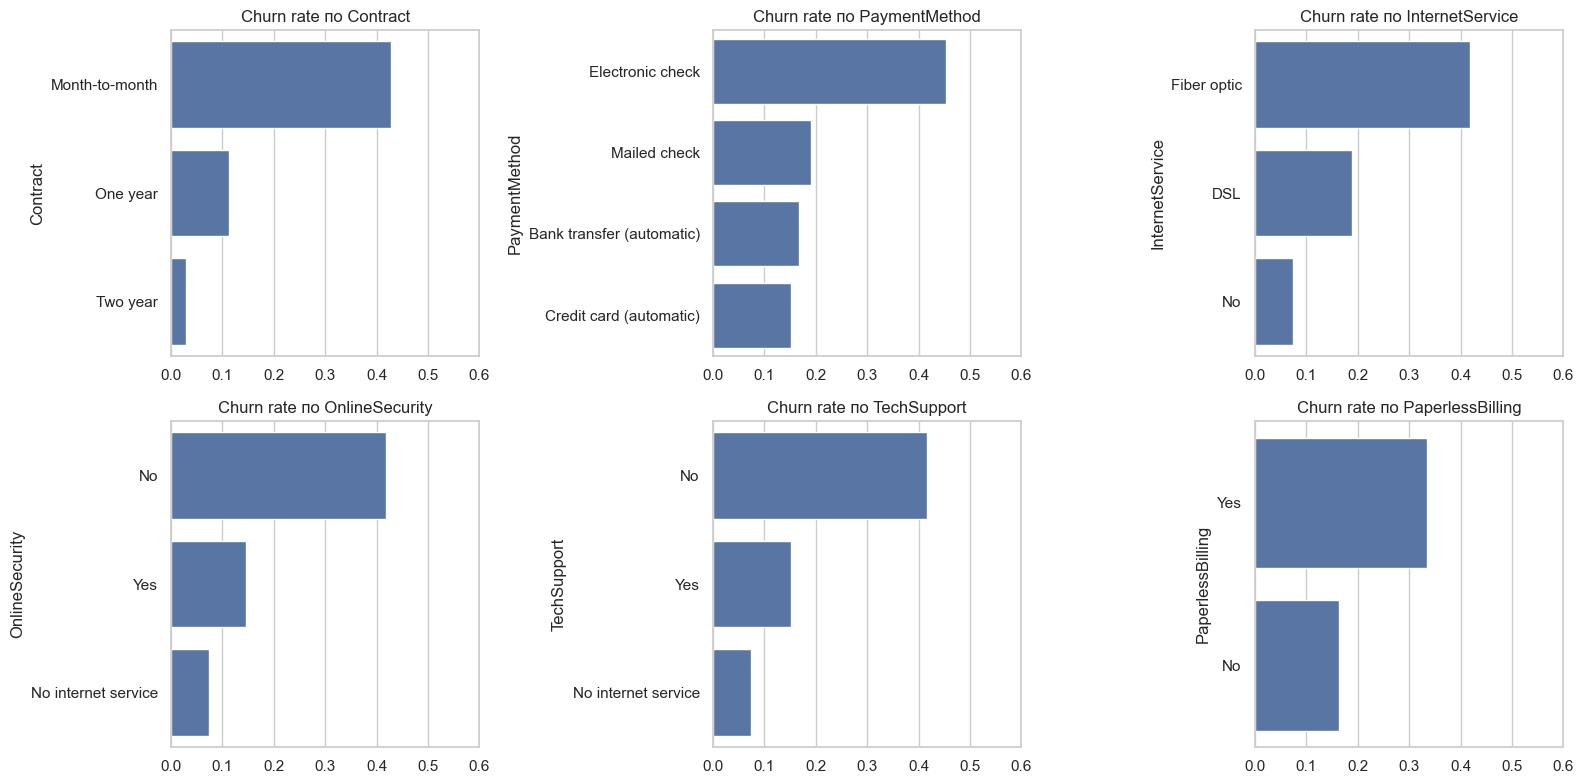

In [9]:
cat_cols = ['Contract', 'PaymentMethod', 'InternetService', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, cat_cols):
    rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, ax=ax, orient='h')
    ax.set_title(f'Churn rate по {col}')
    ax.set_xlim(0, 0.6)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_churn_by_category.png', dpi=200, bbox_inches='tight')
plt.show()

**Наблюдения:**
- Контракт `Month-to-month` — самый рискованный (~43% ухода) против `Two year` (~3%).
- Оплата `Electronic check` ассоциирована с высоким churn.
- Отсутствие `OnlineSecurity` и `TechSupport` повышает риск ухода.
- `PaperlessBilling=Yes` — выше churn.

## 6. Корреляция числовых признаков

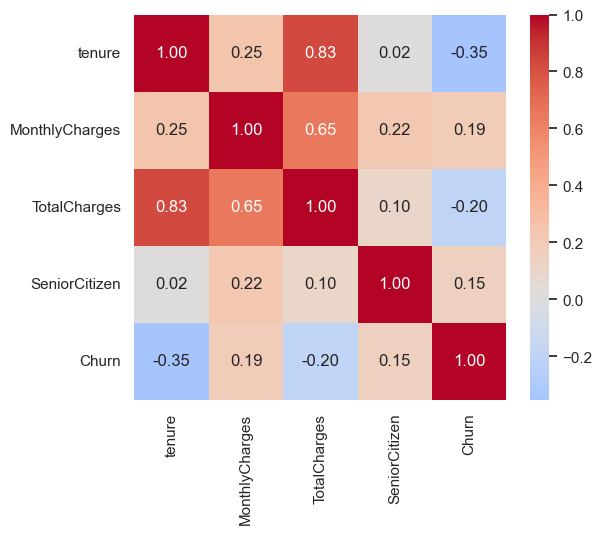

In [10]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
fig.savefig(FIG_DIR / 'fig_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

## Выводы EDA

1. Размер датасета: 7043 строк, 21 колонка. После удаления `customerID` остаётся 20 признаков.
2. Целевая переменная несбалансирована (~26.5% Churn=1). Метрики: ROC-AUC, F1, precision, recall. Для тренировки — `class_weight='balanced'`.
3. Пропусков нет (после приведения `TotalCharges` к числу и заполнения нулями для tenure=0).
4. Сильнейшие предикторы по EDA: `tenure`, `Contract`, `PaymentMethod`, `OnlineSecurity`, `TechSupport`, `MonthlyCharges`.
5. Числовые признаки → StandardScaler; категориальные → OneHotEncoder.
6. Сплит train/test: 80/20, стратифицированный по `Churn`, `random_state=42`.